Top 10 Highly Correlated Pairs:
coord_mean        Nt                 1.000000
connectivity      coord_std          0.964497
Deff_x            porosity           0.955490
coord_mean        coord_std          0.953349
coord_std         Nt                 0.953339
connectivity      Nt                 0.949969
                  coord_mean         0.949966
Kx                Deff_x             0.935678
                  porosity           0.856406
throat_diam_mean  throat_diam_std    0.806158
dtype: float64
Total variance explained by first 2 PCs: 74.55%
Total variance explained by first 3 PCs: 83.88%
Total variance explained by first 4 PCs: 92.01%

Top Loadings for PC1 (Primary variance driver):
Deff_x              0.417316
porosity            0.408063
throat_diam_mean    0.397761
Kx                  0.394542
throat_diam_std     0.375764
throat_ratio        0.322319
coord_std           0.084969
coord_mean          0.083872
Np                  0.014251
tau_x              -0.293102
Name: PC1,

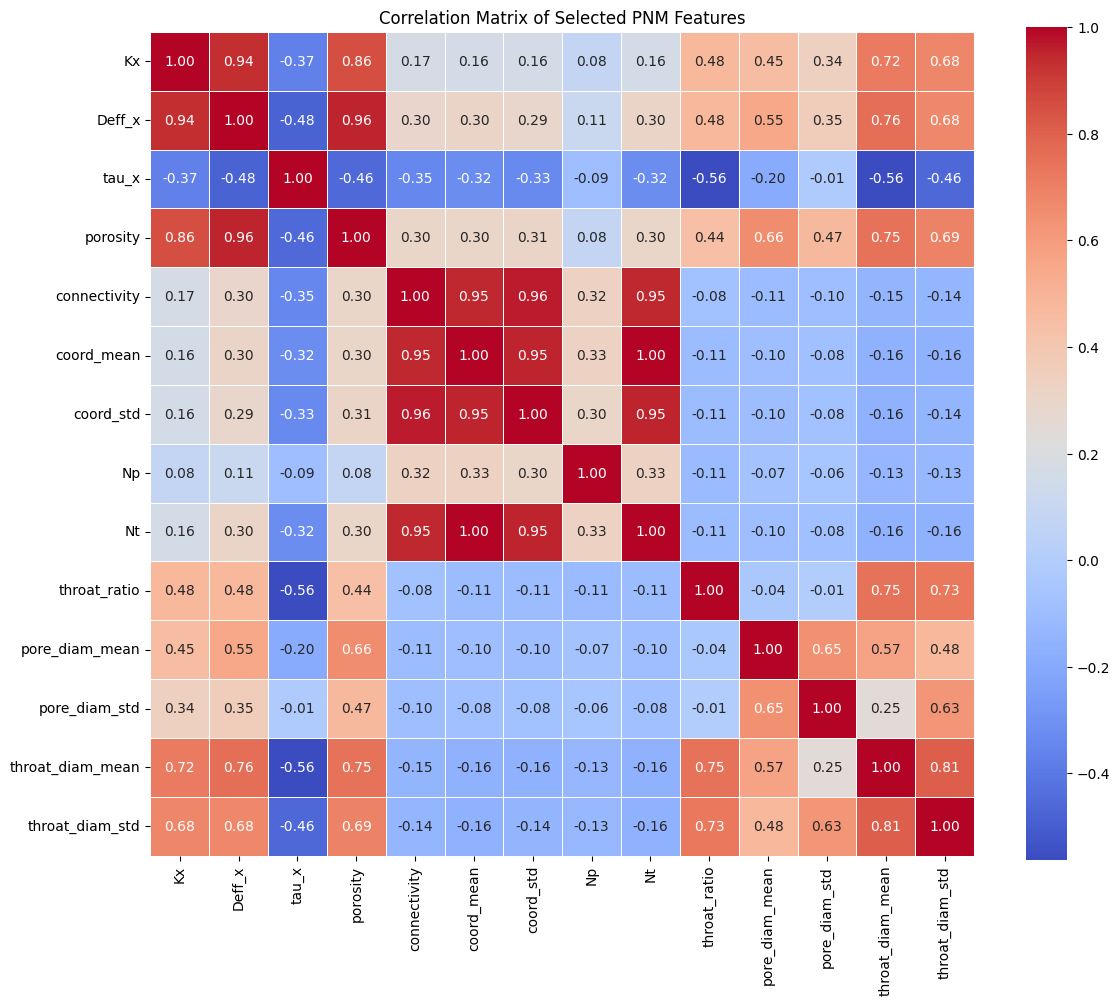

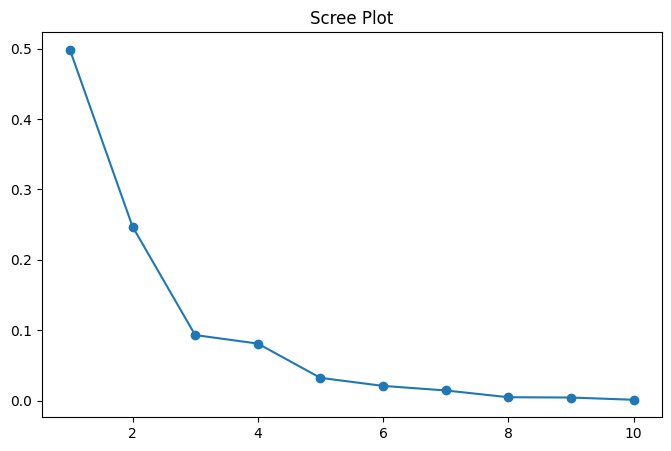

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
# Load the dataset
df = pd.read_excel('pnm_dataset_all_versions.xlsx',sheet_name = 'clean_285')

#first check the dataset
#print(df.info())

# check the covariance of variables
corr_matrix = X.corr()

# 2. Visualization using a Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=.5)
plt.title('Correlation Matrix of Selected PNM Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')

# Display highly correlated pairs
sol = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
                  .stack()
                  .sort_values(ascending=False))

print("Top 10 Highly Correlated Pairs:")
print(sol.head(10))

'''
Top 10 Highly Correlated Pairs:
coord_mean        Nt                 1.000000
connectivity      coord_std          0.964497
Deff_x            porosity           0.955490
coord_mean        coord_std          0.953349
coord_std         Nt                 0.953339
connectivity      Nt                 0.949969
                  coord_mean         0.949966
Kx                Deff_x             0.935678
                  porosity           0.856406
throat_diam_mean  throat_diam_std    0.806158
'''


# 1. Explicitly select the "Wanted" features for PCA
# These features describe the transport, topology, and geometry of the network.
selected_features = [
    'Kx', 'Deff_x', 'tau_x',              # Transport properties
    'porosity',                           # Bulk property
    'coord_mean', 'coord_std',            # Topology/Connectivity
    'Np',                                 # Node/Throat counts
    'throat_ratio',                       # Geometric ratio
    'throat_diam_mean', 'throat_diam_std' # Throat geometry
]

# Create the feature matrix X
X = df[selected_features]

# 2. Scaling (Essential for PCA since units like Kx and porosity differ vastly)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. PCA Analysis
pca = PCA(n_components=len(selected_features))
X_pca = pca.fit_transform(X_scaled)

# 4. Results Analysis
explained_var = pca.explained_variance_ratio_
print(f"Total variance explained by first 2 PCs: {sum(explained_var[:2]):.2%}")
print(f"Total variance explained by first 3 PCs: {sum(explained_var[:3]):.2%}")
print(f"Total variance explained by first 4 PCs: {sum(explained_var[:4]):.2%}")
# generate a scree plot to visualize the variance explained by each PC
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(selected_features) + 1), explained_var, marker='o')
plt.title('Scree Plot')

# 5. Loadings: View which variables contribute most to PC1
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(len(selected_features))], 
    index=selected_features
)
print("\nTop Loadings for PC1 (Primary variance driver):")
print(loadings['PC1'].sort_values(ascending=False))